# SHAP Bar Plot

This notebook demonstrates how to use `shap.plots.bar` to visualize feature importance from SHAP explanations. The bar plot is one of the most versatile SHAP visualizations — it can show **global** importance across a dataset, **local** importance for a single prediction, and **cohort** comparisons between groups.

**What you will learn:**
- What SHAP values represent and why they are useful
- The difference between local (per-sample) and global (dataset-wide) importance
- How to use `shap.plots.bar` in multiple ways
- How to reveal feature redundancy using hierarchical clustering

**Requirements:** `shap`, `xgboost`, `scikit-learn`

## 1. Setup and Imports

In [1]:
import numpy as np
import xgboost

import shap

# Set random seed for reproducibility
np.random.seed(0)

## 2. Dataset and Model Training

We use the Wisconsin Breast Cancer dataset  from scikit-learn. It contains 30 numeric features (such as cell radius, texture, and smoothness) measured from digitized images of fine needle aspirates. The binary target indicates whether a tumor is **malignant (0)** or **benign (1)**.

We train an XGBoost classifier, a gradient-boosted tree ensemble that is both powerful and natively supported by SHAP's TreeExplainer for fast, exact SHAP value computation.

In [2]:
from sklearn.datasets import load_breast_cancer

# Load dataset
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target

print(f"Dataset shape: {X.shape}")
print(f"Features: {list(X.columns)}")
print("Target: 0 = Malignant, 1 = Benign")

Dataset shape: (569, 30)
Features: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']
Target: 0 = Malignant, 1 = Benign


In [3]:
# Train an XGBoost classifier
model = xgboost.XGBClassifier(
    n_estimators=100,
    random_state=0,
    eval_metric="logloss",
)
model.fit(X, y)

print(f"Model training accuracy: {model.score(X, y):.4f}")

Model training accuracy: 1.0000


## 3. Computing SHAP Values

**SHAP (SHapley Additive exPlanations)** values come from cooperative game theory. For any prediction, each feature receives a SHAP value that quantifies its contribution to the difference between the model's prediction and the average prediction.

- A **positive** SHAP value means the feature pushed the prediction *higher* (toward benign).
- A **negative** SHAP value means the feature pushed the prediction *lower* (toward malignant).
- The **sum** of SHAP values equals the difference between the model output for the instance and the expected value (baseline)..

`shap.Explainer` automatically detects the model type and selects the best algorithm — in this case **TreeExplainer**, which is exact and highly efficient for tree-based models.

In [4]:
# Create an explainer — auto-detects TreeExplainer for XGBoost
explainer = shap.Explainer(model, X)

# Compute SHAP values for the full dataset
# Returns an Explanation object (not just a raw array)
shap_values = explainer(X)

print(f"SHAP values shape: {shap_values.values.shape}")
print(f"Type: {type(shap_values)}")

SHAP values shape: (569, 30)
Type: <class 'shap._explanation.Explanation'>


## 4. Visualization: Bar Plot Variations

The `shap.plots.bar` function is flexible and changes behavior based on what you pass to it. Below we explore the most useful variations.

### 4.1 Default Global Bar Plot

Passing the full `Explanation` object creates a **global feature importance** plot. By default, SHAP computes the mean absolute SHAP value for each feature across all samples — this tells you which features, on average, have the greatest influence on predictions.

By default, `shap.plots.bar` shows the top 10 features.

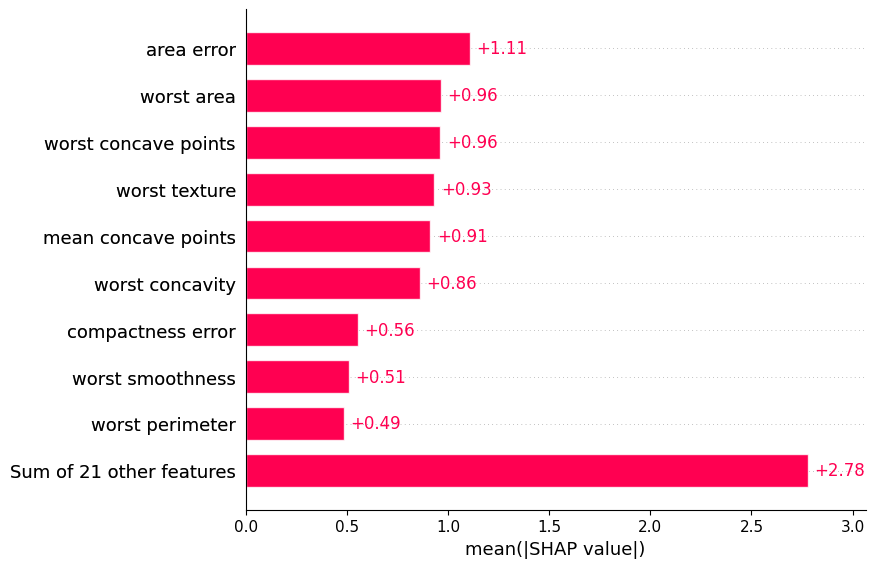

In [5]:
shap.plots.bar(shap_values)

### 4.2 Controlling the Number of Features

Use the `max_display` parameter to show more or fewer features. The remaining features are grouped into an "other features" bar so importance is never hidden.

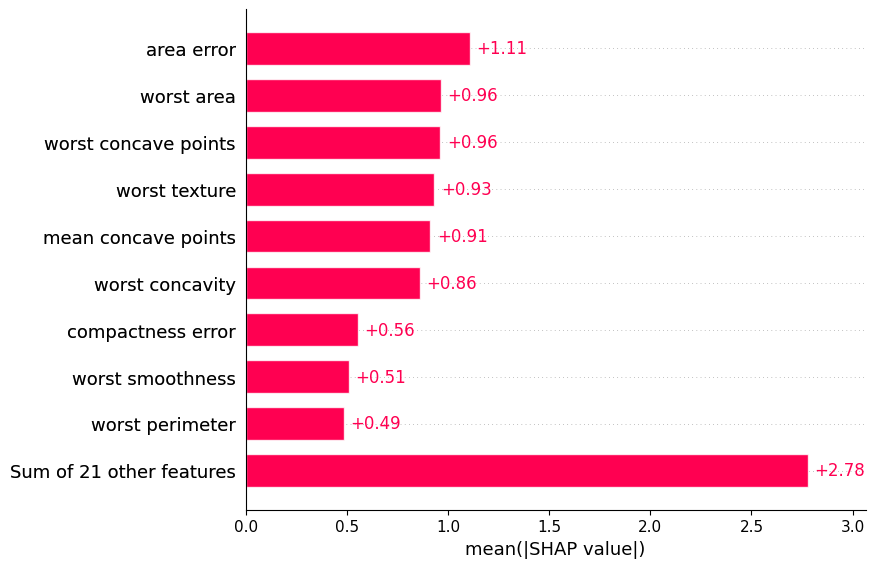

In [6]:
shap.plots.bar(shap_values, max_display=10)

### 4.3 Explicit Global Importance via `.abs.mean(0)`

You can make the aggregation explicit: take the absolute value of all SHAP values, then average across samples (axis 0). This is equivalent to the default behavior but makes the intent clear, and is useful when you want to further process or inspect the aggregated values before plotting.

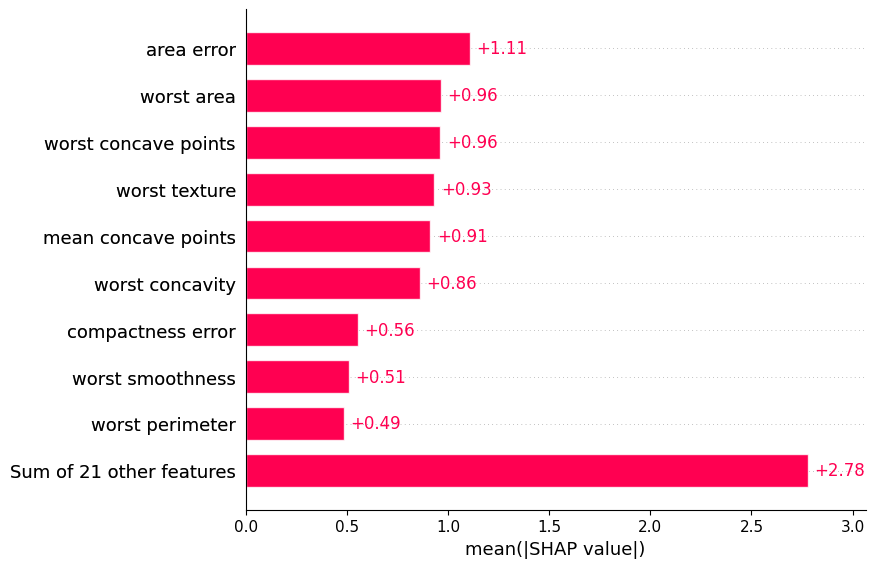

In [7]:
# This explicitly computes global importance instead of relying on internal defaults.
shap.plots.bar(shap_values.abs.mean(0))

### 4.4 Local Bar Plot — Single Sample

**Local explanations** show how features influenced a *specific* prediction. Passing a single row (`shap_values[i]`) plots the signed SHAP values for that instance:

- Bars pointing **right** (positive) pushed the prediction toward benign.
- Bars pointing **left** (negative) pushed the prediction toward malignant.
- Feature values are displayed in gray to the left of each feature name.

This is the key difference from global plots: here bars represent *actual contributions* for one sample, not averages.

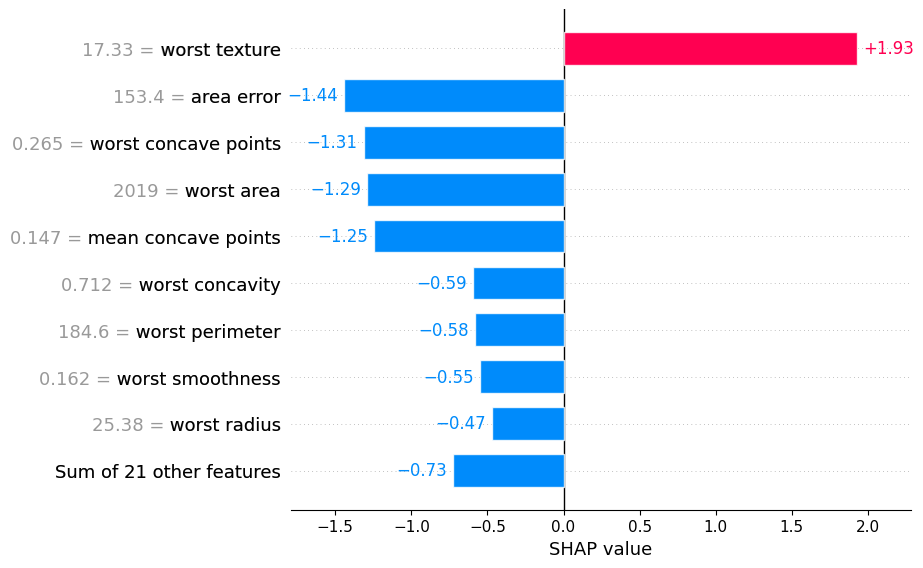

In [8]:
# Explain the first sample
shap.plots.bar(shap_values[0])

### 4.5 Cohort Bar Plot — Comparing Groups

The cohort bar plot is a powerful way to compare feature importance across **subgroups**. Here we split the dataset by diagnosis (malignant vs. benign) and visualize how each group's SHAP importances differ.

Internally, `shap_values.cohorts(labels)` creates a dictionary of `Explanation` objects — one per cohort. Calling `.abs.mean(0)` reduces each cohort to its mean absolute SHAP values for the bar chart.

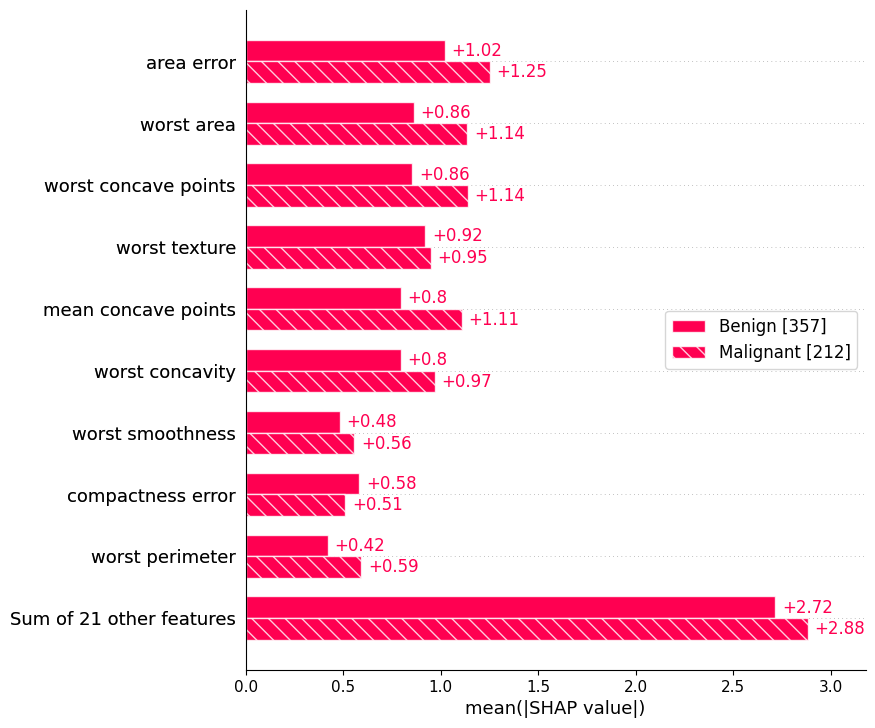

In [9]:
# Create cohort labels from the ground-truth target
diagnosis = ["Malignant" if v == 0 else "Benign" for v in y]

# Plot global importance separately for each cohort
shap.plots.bar(shap_values.cohorts(diagnosis).abs.mean(0))

### 4.6 Auto-Cohort Discovery

If you don't have predefined groups, SHAP can automatically discover cohorts by fitting a decision tree on the SHAP values. `shap_values.cohorts(N)` splits the dataset into `N` groups that best separate SHAP behavior — revealing structurally different subpopulations in your data.

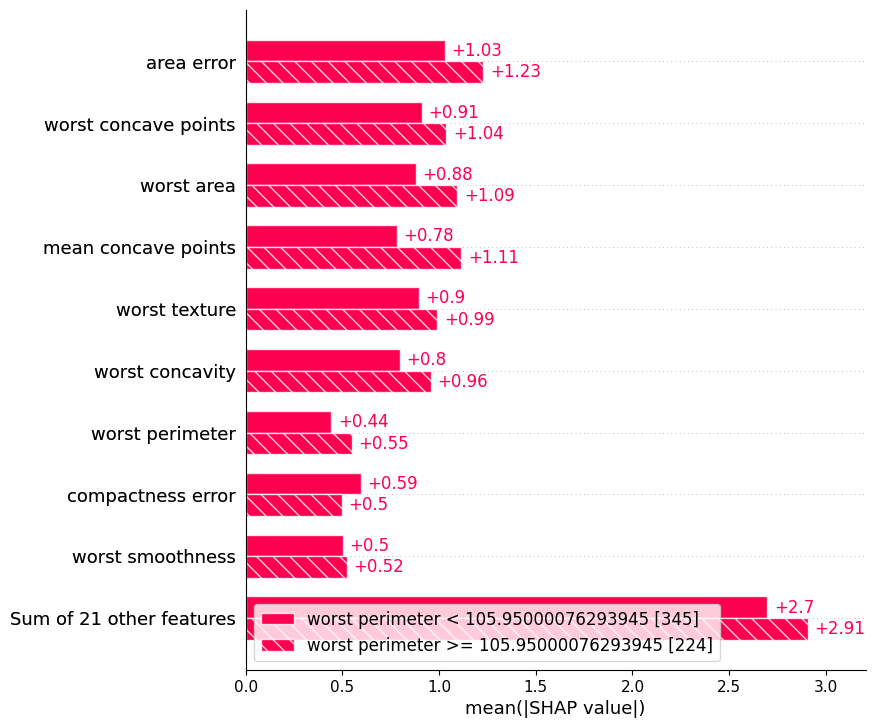

In [10]:
# Auto-discover 2 cohorts based on SHAP value structure
shap.plots.bar(shap_values.cohorts(2).abs.mean(0))

## 5. Feature Clustering

Datasets often contain **redundant features** — features that are interchangeable from the model's perspective (e.g., `mean radius` and `mean perimeter` in this dataset are highly correlated).

`shap.utils.hclust` builds a hierarchical clustering of features based on **model loss comparisons**: it trains pairwise XGBoost models for each feature pair and measures how interchangeable they are. This is more meaningful than correlation-based clustering because it directly measures model-level redundancy.

The clustering can then be overlaid on the bar plot to reveal feature groupings alongside their importances.

In [11]:
# Compute hierarchical clustering based on feature redundancy
# This can be computationally expensive for datasets with many features.
clustering = shap.utils.hclust(X, y)

901it [00:11, 10.63it/s]                          


### 5.1 Bar Plot with Clustering (default cutoff = 0.5)

By default, only feature groups with clustering distance < 0.5 are shown as merged bars. A distance of 0 means features are perfectly redundant; a distance of 1 means completely independent. This conservative threshold highlights only the strongest redundancies.

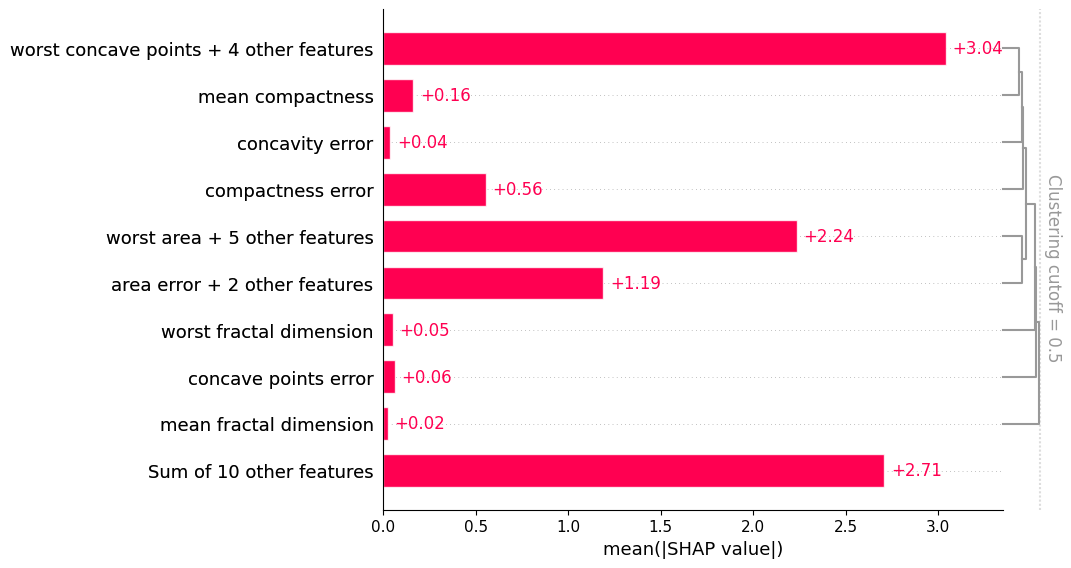

In [12]:
shap.plots.bar(shap_values, clustering=clustering)

### 5.2 Increasing the Clustering Cutoff

Raising `clustering_cutoff` to 0.9 reveals more of the hierarchical structure. Note that the feature ordering is now constrained to follow valid cluster-leaf orderings, and features within each cluster are sorted by importance.

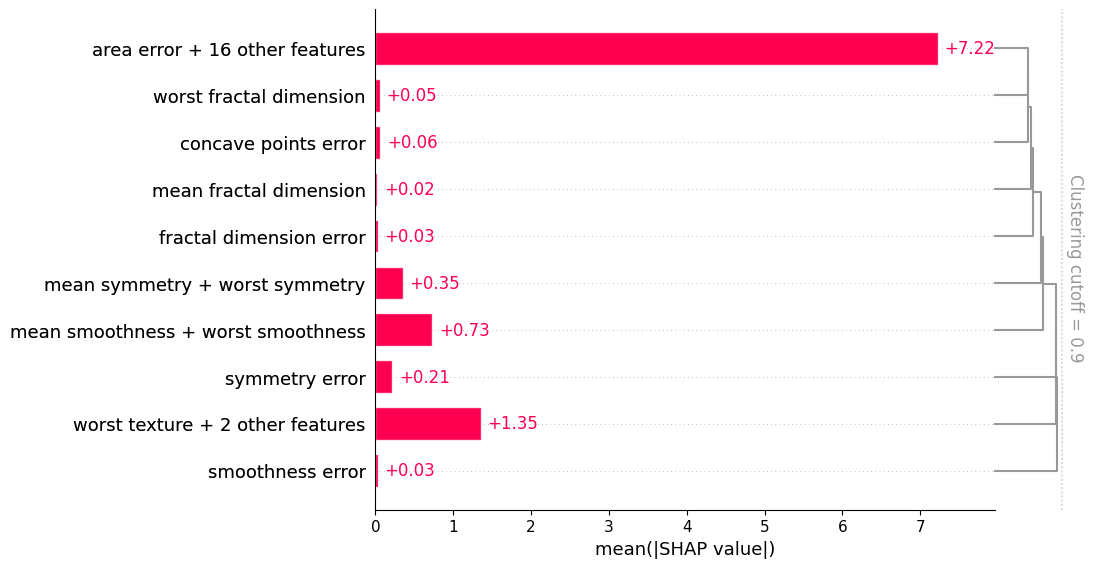

In [13]:
shap.plots.bar(shap_values, clustering=clustering, clustering_cutoff=0.9)

## 6. Partition Explainer with Built-in Clustering

Some explainers — notably `shap.maskers.Partition` — embed the clustering into the `Explanation` object itself. This masker avoids perturbing features in unrealistic combinations by only masking features within coherent clusters.

When a clustering is embedded in the `Explanation`, `shap.plots.bar` picks it up automatically without you needing to pass it explicitly.

In [14]:
# SAFE clustering (prevents RAM crash)
subset_idx = np.random.choice(len(X), size=100, replace=False)
X_subset = X.iloc[subset_idx]
y_subset = y.iloc[subset_idx]

clustering = shap.utils.hclust(X_subset, y_subset)


# Define model function
def f(x):
    return model.predict(x)


# Create masker (now it will NOT crash)
masker = shap.maskers.Partition(X_subset, clustering=clustering)

# Explainer
explainer_partition = shap.Explainer(f, masker)

# Compute SHAP values
shap_values_partition = explainer_partition(X_subset)

print(f"Partition SHAP values shape: {shap_values_partition.shape}")

ExactExplainer explainer: 101it [25:03, 15.03s/it]

Partition SHAP values shape: (100, 30)


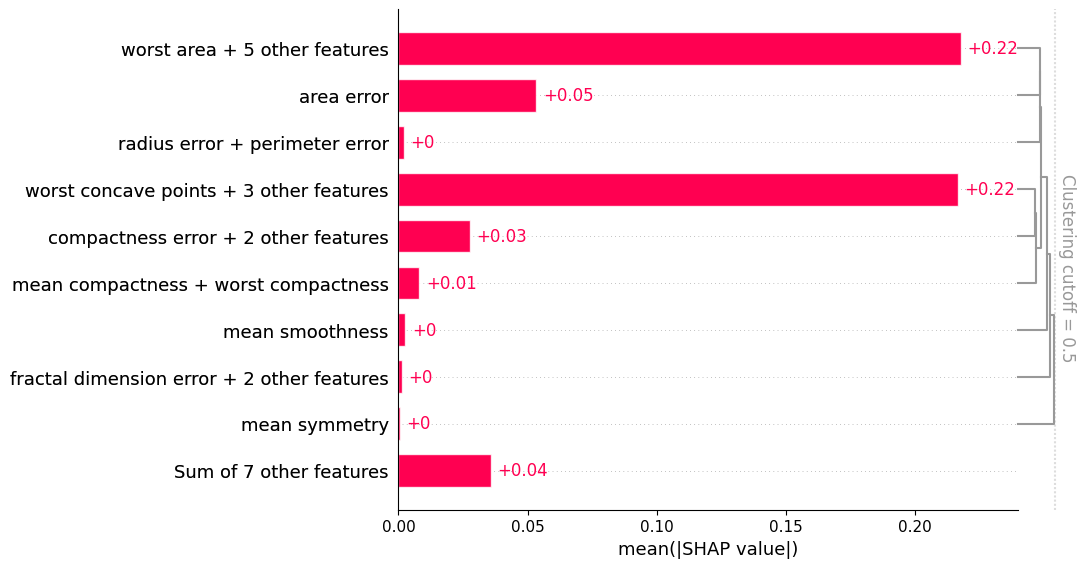

In [15]:
# Clustering is embedded — no need to pass it explicitly
shap.plots.bar(shap_values_partition)

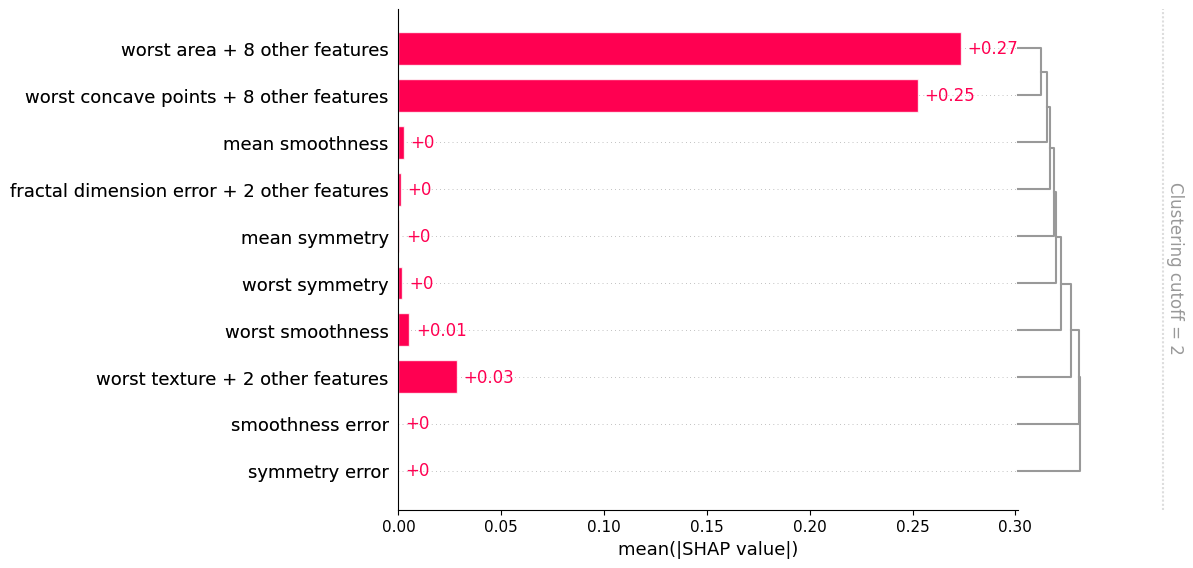

In [16]:
# Show more cluster structure with a higher cutoff
shap.plots.bar(shap_values_partition, clustering_cutoff=2)

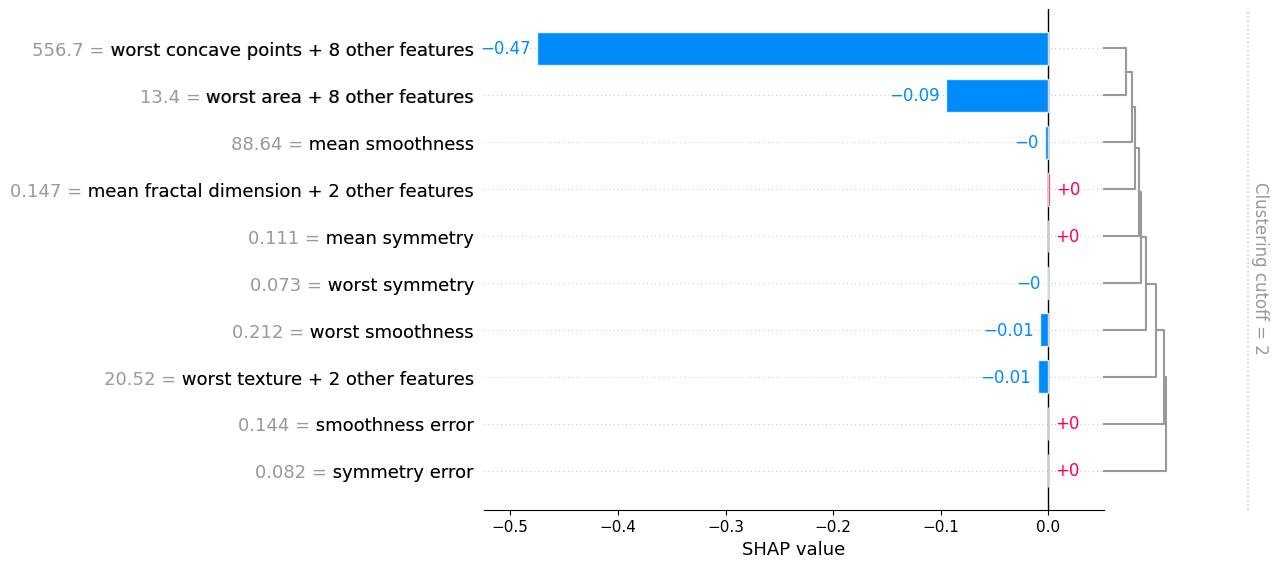

In [17]:
# Local explanation with clustering for the first sample
shap.plots.bar(shap_values_partition[0], clustering_cutoff=2)

## Summary

| Plot Call | What It Shows |
|-----------|---------------|
| `shap.plots.bar(shap_values)` | Global importance: mean \|SHAP\| per feature, top 10 |
| `shap.plots.bar(shap_values, max_display=10)` | Same, but control number of bars shown |
| `shap.plots.bar(shap_values.abs.mean(0))` | Explicit global importance aggregation |
| `shap.plots.bar(shap_values[0])` | Local importance: signed SHAP values for one sample |
| `shap.plots.bar(shap_values.cohorts(labels).abs.mean(0))` | Per-cohort global importance side by side |
| `shap.plots.bar(shap_values, clustering=clustering)` | Global importance with feature redundancy structure |

---

Have an idea for more helpful examples? Pull requests that add to this documentation notebook are encouraged!